
SURVIVALVR-BD KNOWLEDGE GRAPH BUILDER
Standalone Version - No external dependencies

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!
Output folder created: /content/drive/MyDrive/SurvivalVR_Outputs

[2] Building Knowledge Graph from 15 skills...
[3] Graph built: 53 nodes, 45 edges
[1] KnowledgeGraphBuilder initialized with 15 skills

KNOWLEDGE GRAPH SUMMARY

Total Nodes: 53
Total Edges: 45

Nodes by Type:
   - category: 8
   - conclusion: 15
   - condition: 15
   - skill: 15

Skills by Category:
   - navigation: 3 skills
   - survival: 2 skills
   - fishing: 2 skills
   - training: 2 skills
   - emergency: 2 skills
   - decision_making: 2 skills
   - weather: 1 skills
   - safety: 1 skills

Sample Skills (First 5):
   1. Current Direction Reading (Confidence: 0.95)
   2. Fish Oil Fire Making (Confidence: 0.92)
   3. Star Navigation (Confidence: 0.89)
   4. Bird Behavior 

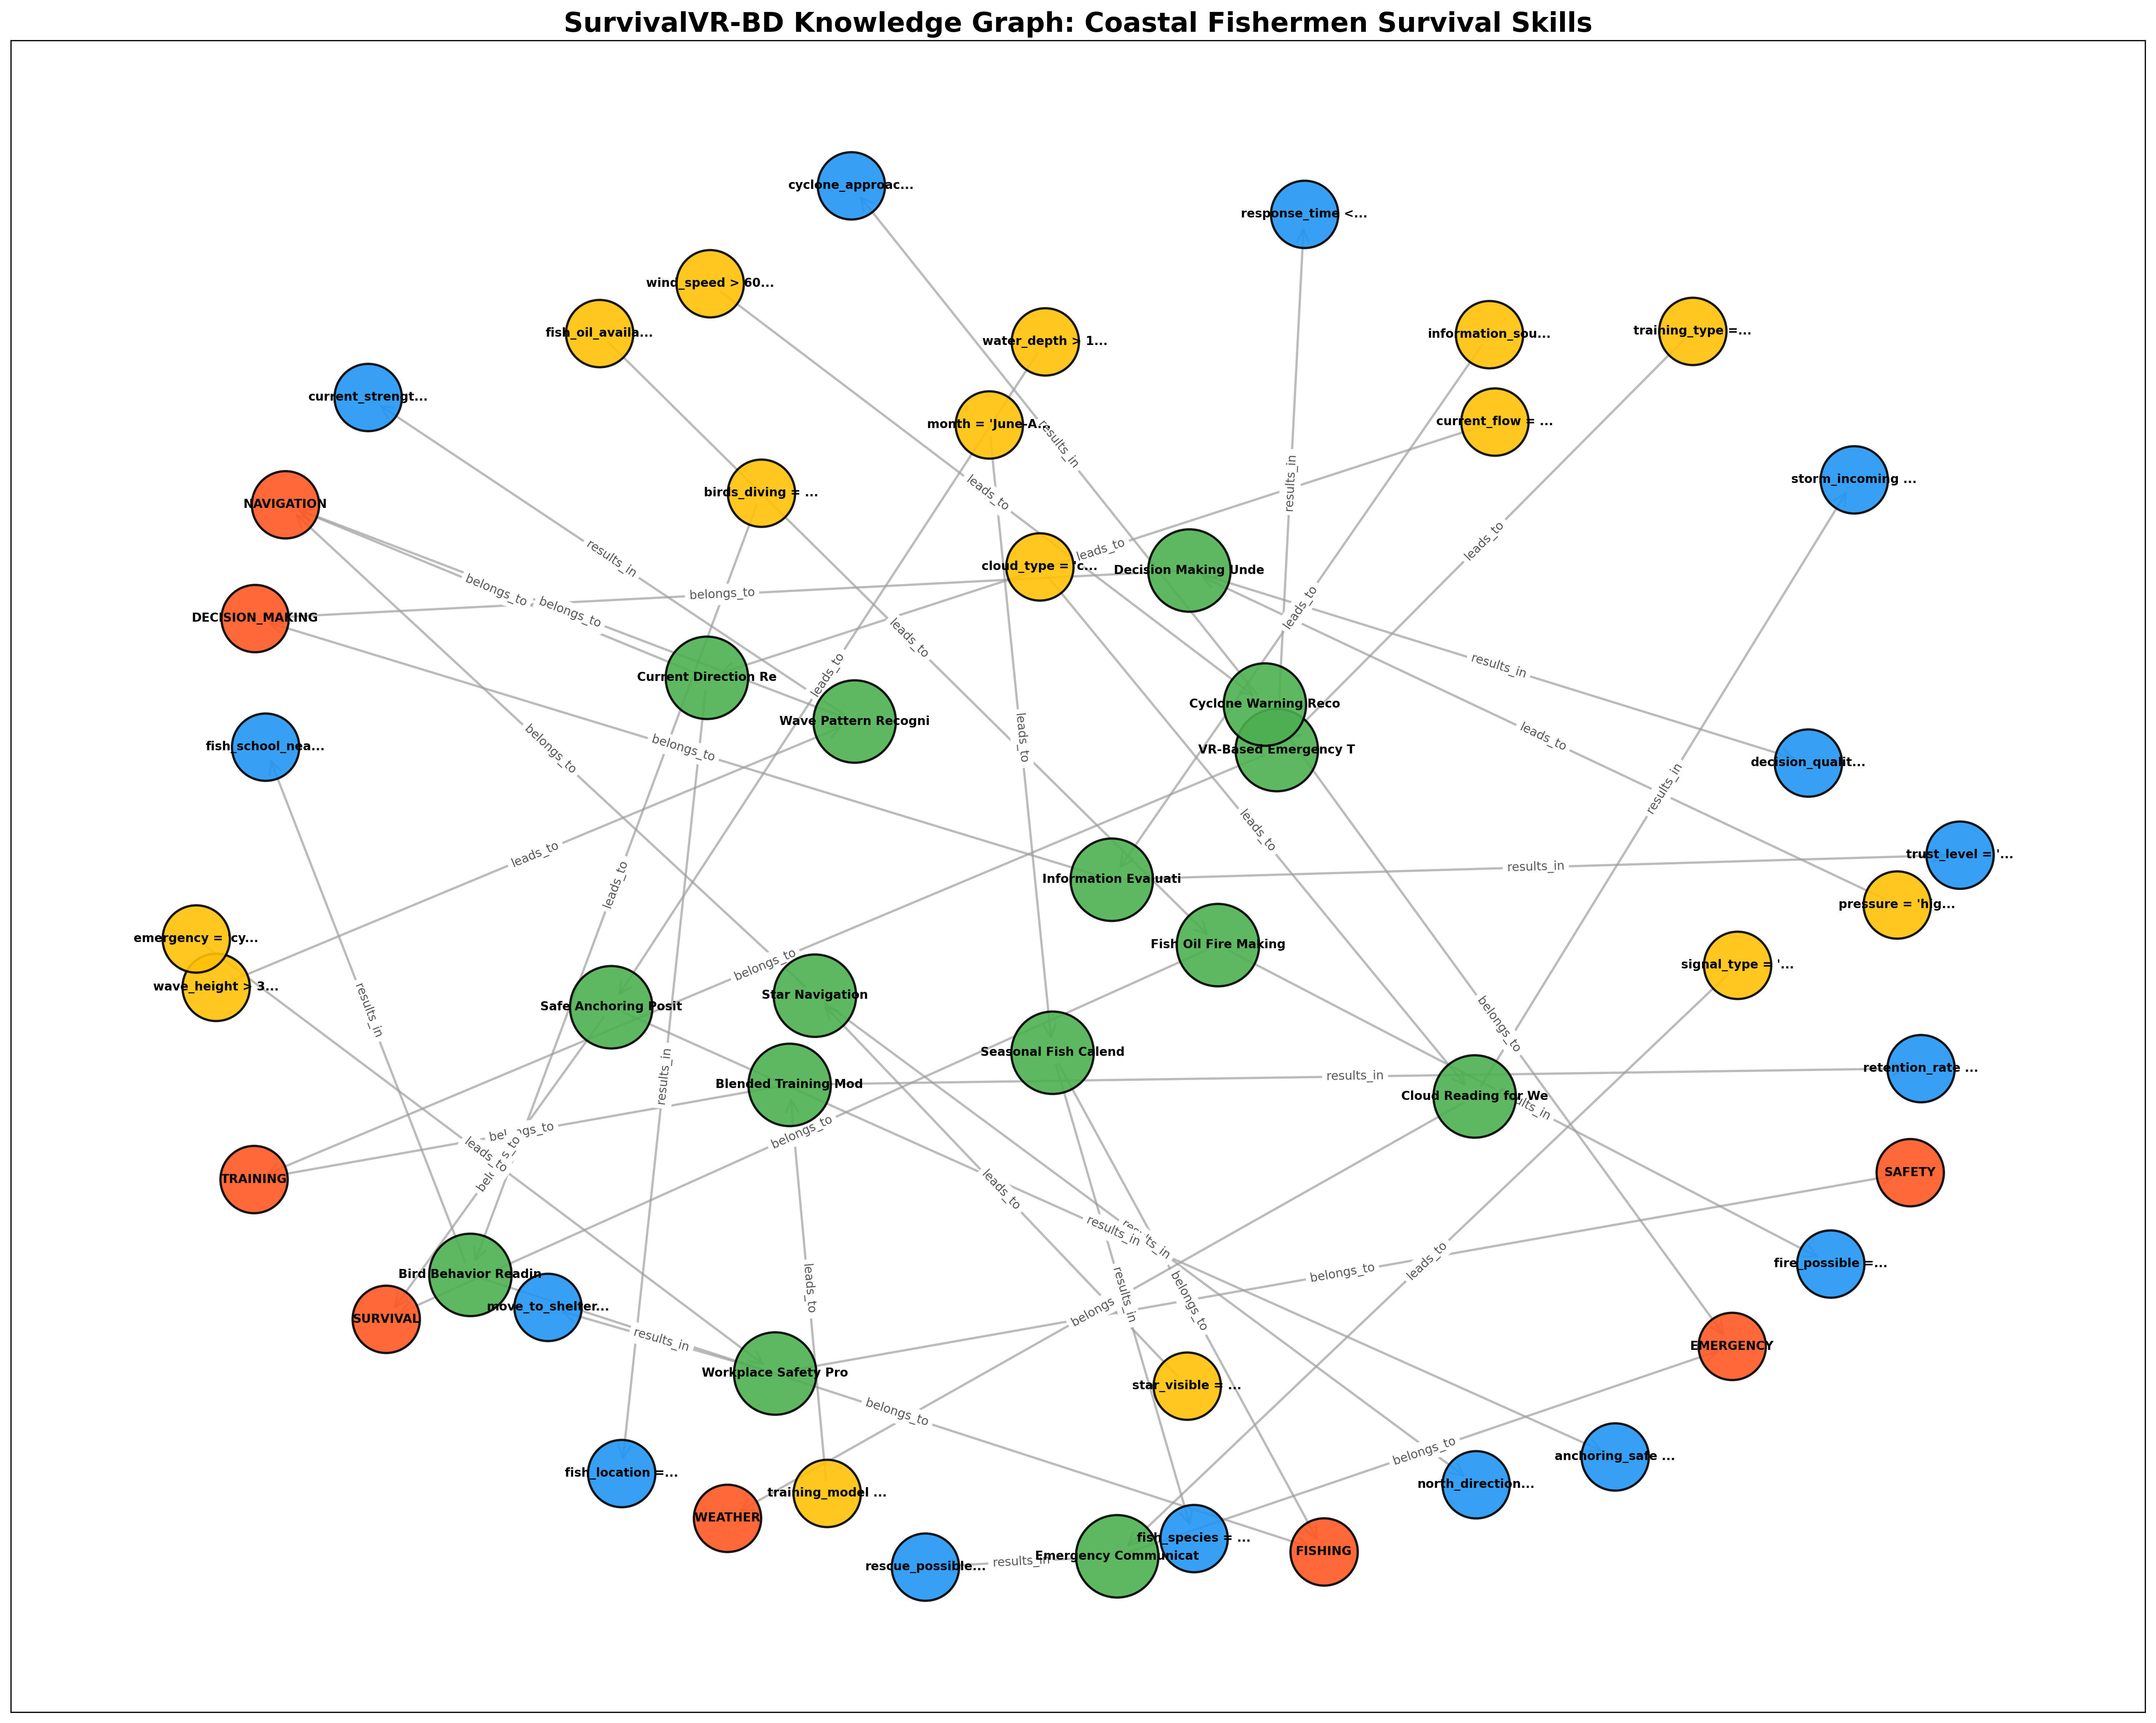

Graph displayed in notebook!


In [3]:
# =====================================================
# knowledge_graph_builder.py - STANDALONE VERSION
# No external dependencies - Works in Colab
# =====================================================

import json
import networkx as nx
import matplotlib.pyplot as plt
from typing import Dict, List
from datetime import datetime
import os
import shutil

# =====================================================
# EMBEDDED DATA - No external file needed
# =====================================================

SURVIVAL_SKILLS_DATA = [
    # SOURCE 1: ScienceDirect 2018 - Ethnographic Study
    {
        "skill_id": "SK_001",
        "skill": "Current Direction Reading",
        "description": "Fishermen determine fish location by reading current direction. Water color indicates depth and fish presence.",
        "source": "ScienceDirect 2018",
        "source_type": "Ethnographic Study",
        "action": "IF current_flow = 'towards_shore' AND water_color = 'dark_green' THEN fish_location = 'deep_water'",
        "confidence": 0.95,
        "category": "navigation",
        "keywords": ["current", "direction", "water color", "fish location"]
    },
    {
        "skill_id": "SK_002",
        "skill": "Fish Oil Fire Making",
        "description": "Method of starting fire using fish oil and dry wood. Fish oil acts as an accelerant.",
        "source": "ScienceDirect 2018",
        "source_type": "Ethnographic Study",
        "action": "IF fish_oil_available = True AND dry_wood_available = True THEN fire_possible = True",
        "confidence": 0.92,
        "category": "survival",
        "keywords": ["fire", "fish oil", "wood", "ignition"]
    },
    {
        "skill_id": "SK_003",
        "skill": "Star Navigation",
        "description": "Using star constellations for direction at night. Polaris indicates North.",
        "source": "ScienceDirect 2018",
        "source_type": "Ethnographic Study",
        "action": "IF star_visible = True AND constellation = 'Ursa_Major' THEN north_direction_found = True",
        "confidence": 0.89,
        "category": "navigation",
        "keywords": ["stars", "navigation", "Polaris", "constellation"]
    },
    {
        "skill_id": "SK_004",
        "skill": "Bird Behavior Reading",
        "description": "Diving birds indicate fish schools below the surface. Number of birds indicates fish density.",
        "source": "ScienceDirect 2018",
        "source_type": "Ethnographic Study",
        "action": "IF birds_diving = True AND birds_count > 10 THEN fish_school_nearby = True",
        "confidence": 0.88,
        "category": "fishing",
        "keywords": ["birds", "diving", "fish school", "location"]
    },

    # SOURCE 2: Frontiers 2021 - FGD Report
    {
        "skill_id": "SK_005",
        "skill": "Cloud Reading for Weather Prediction",
        "description": "Cloud color and shape indicate weather patterns. Cumulonimbus clouds indicate approaching storms.",
        "source": "Frontiers 2021",
        "source_type": "FGD Report",
        "action": "IF cloud_type = 'cumulonimbus' AND cloud_height = 'high' THEN storm_incoming = True",
        "confidence": 0.88,
        "category": "weather",
        "keywords": ["clouds", "weather", "storm", "prediction", "cumulonimbus"]
    },
    {
        "skill_id": "SK_006",
        "skill": "Wave Pattern Recognition",
        "description": "Wave patterns indicate underwater topography and current strength.",
        "source": "Frontiers 2021",
        "source_type": "FGD Report",
        "action": "IF wave_height > 3 AND wave_frequency = 'high' THEN current_strength = 'strong'",
        "confidence": 0.84,
        "category": "navigation",
        "keywords": ["waves", "current", "topography", "pattern"]
    },
    {
        "skill_id": "SK_007",
        "skill": "Seasonal Fish Calendar",
        "description": "Fish species availability changes with seasons. Different fish appear in different months.",
        "source": "Frontiers 2021",
        "source_type": "FGD Report",
        "action": "IF month = 'June-August' THEN fish_species = 'Hilsa' AND location = 'near_shore'",
        "confidence": 0.87,
        "category": "fishing",
        "keywords": ["season", "fish", "calendar", "monthly"]
    },

    # SOURCE 3: NDC 2021 - VR Training Study
    {
        "skill_id": "SK_008",
        "skill": "VR-Based Emergency Training",
        "description": "Virtual Reality can effectively train emergency response skills for fishermen.",
        "source": "NDC 2021",
        "source_type": "VR Training Study",
        "action": "IF training_type = 'VR_emergency' AND hours_trained > 4 THEN response_time < 60_seconds",
        "confidence": 0.82,
        "category": "training",
        "keywords": ["VR", "emergency", "training", "response"]
    },
    {
        "skill_id": "SK_009",
        "skill": "Blended Training Model",
        "description": "Combination of classroom and VR training improves retention and performance.",
        "source": "NDC 2021",
        "source_type": "VR Training Study",
        "action": "IF training_model = 'blended' THEN retention_rate > 70_percent",
        "confidence": 0.80,
        "category": "training",
        "keywords": ["blended", "training", "retention", "classroom"]
    },

    # SOURCE 4: ScienceDirect 2024 - Cyclone Study
    {
        "skill_id": "SK_010",
        "skill": "Cyclone Warning Recognition",
        "description": "Identifying cyclone approaching signs: wind speed increase and pressure drop.",
        "source": "ScienceDirect 2024",
        "source_type": "Cyclone Study",
        "action": "IF wind_speed > 60 AND pressure_drop > 20 THEN cyclone_approaching = True",
        "confidence": 0.90,
        "category": "emergency",
        "keywords": ["cyclone", "wind", "pressure", "warning", "storm"]
    },
    {
        "skill_id": "SK_011",
        "skill": "Safe Anchoring Positions",
        "description": "Finding safe anchoring positions during storms based on water depth and seabed type.",
        "source": "ScienceDirect 2024",
        "source_type": "Cyclone Study",
        "action": "IF water_depth > 10 AND seabed_type = 'mud' THEN anchoring_safe = True",
        "confidence": 0.87,
        "category": "survival",
        "keywords": ["anchoring", "depth", "seabed", "safety"]
    },
    {
        "skill_id": "SK_012",
        "skill": "Emergency Communication",
        "description": "Using bright colors and reflective materials to send distress signals.",
        "source": "ScienceDirect 2024",
        "source_type": "Cyclone Study",
        "action": "IF signal_type = 'bright_color' AND visibility = 'clear' THEN rescue_possible = True",
        "confidence": 0.85,
        "category": "emergency",
        "keywords": ["signal", "distress", "rescue", "communication"]
    },

    # SOURCE 5: Information Value Study 2025
    {
        "skill_id": "SK_013",
        "skill": "Information Evaluation",
        "description": "Fishermen evaluate information sources for decision making during emergencies.",
        "source": "Information Value Study 2025",
        "source_type": "Decision Study",
        "action": "IF information_source = 'experienced_fishermen' THEN trust_level = 'high'",
        "confidence": 0.91,
        "category": "decision_making",
        "keywords": ["information", "decision", "trust", "source"]
    },
    {
        "skill_id": "SK_014",
        "skill": "Decision Making Under Pressure",
        "description": "Decision making processes during emergency situations require quick thinking.",
        "source": "Information Value Study 2025",
        "source_type": "Decision Study",
        "action": "IF pressure = 'high' AND response = 'calm' THEN decision_quality = 'good'",
        "confidence": 0.88,
        "category": "decision_making",
        "keywords": ["decision", "pressure", "calm", "quality"]
    },

    # SOURCE 6: BGMEA 2025 - RMG Worker Safety
    {
        "skill_id": "SK_015",
        "skill": "Workplace Safety Protocol",
        "description": "Safety protocols for workers in coastal areas during emergencies.",
        "source": "BGMEA 2025",
        "source_type": "Industry Report",
        "action": "IF emergency = 'cyclone' THEN move_to_shelter = 'within_30_minutes'",
        "confidence": 0.86,
        "category": "safety",
        "keywords": ["safety", "cyclone", "shelter", "emergency"]
    }
]


# =====================================================
# KNOWLEDGE GRAPH BUILDER CLASS
# =====================================================

class KnowledgeGraphBuilder:
    """
    Builds Knowledge Graph from embedded survival skills data
    """

    def __init__(self):
        """Initialize with embedded data"""
        self.graph = nx.DiGraph()
        self.skills_data = SURVIVAL_SKILLS_DATA
        self.node_count = 0
        self.edge_count = 0
        self._build_graph()
        print(f"[1] KnowledgeGraphBuilder initialized with {len(self.skills_data)} skills")

    def _build_graph(self):
        """Build Knowledge Graph from embedded data"""
        print(f"[2] Building Knowledge Graph from {len(self.skills_data)} skills...")

        for idx, skill in enumerate(self.skills_data):
            # Create Skill Node
            skill_id = f"SK_{idx:03d}"
            self.graph.add_node(
                skill_id,
                name=skill.get('skill', f'Skill_{idx}'),
                description=skill.get('description', ''),
                source=skill.get('source', 'Unknown'),
                source_type=skill.get('source_type', ''),
                confidence=skill.get('confidence', 0.0),
                category=skill.get('category', 'unknown'),
                type='skill',
                keywords=skill.get('keywords', [])
            )

            # Parse action: IF condition THEN conclusion
            action = skill.get('action', '')
            if ' THEN ' in action:
                parts = action.split(' THEN ')
                if len(parts) == 2:
                    condition_raw, conclusion = parts

                    # Condition Node
                    cond_id = f"COND_{idx:03d}"
                    condition_text = condition_raw.replace('IF ', '').strip()
                    self.graph.add_node(
                        cond_id,
                        type='condition',
                        text=condition_text,
                        confidence=skill.get('confidence', 0.0)
                    )
                    self.graph.add_edge(cond_id, skill_id, relation='leads_to')

                    # Conclusion Node
                    conc_id = f"CONC_{idx:03d}"
                    self.graph.add_node(
                        conc_id,
                        type='conclusion',
                        text=conclusion.strip(),
                        confidence=skill.get('confidence', 0.0)
                    )
                    self.graph.add_edge(skill_id, conc_id, relation='results_in')

                    # Category node
                    cat_id = f"CAT_{skill.get('category', 'unknown')}"
                    self.graph.add_node(
                        cat_id,
                        type='category',
                        name=skill.get('category', 'unknown')
                    )
                    self.graph.add_edge(skill_id, cat_id, relation='belongs_to')

        self.node_count = self.graph.number_of_nodes()
        self.edge_count = self.graph.number_of_edges()
        print(f"[3] Graph built: {self.node_count} nodes, {self.edge_count} edges")

    def get_graph(self) -> nx.DiGraph:
        """Return the NetworkX graph"""
        return self.graph

    def display_summary(self):
        """Display graph summary"""
        print("\n" + "="*70)
        print("KNOWLEDGE GRAPH SUMMARY")
        print("="*70)

        print(f"\nTotal Nodes: {self.node_count}")
        print(f"Total Edges: {self.edge_count}")

        # Nodes by type
        node_types = {}
        for node, data in self.graph.nodes(data=True):
            ntype = data.get('type', 'unknown')
            node_types[ntype] = node_types.get(ntype, 0) + 1

        print("\nNodes by Type:")
        for ntype, count in sorted(node_types.items()):
            print(f"   - {ntype}: {count}")

        # Nodes by category
        categories = {}
        for node, data in self.graph.nodes(data=True):
            if data.get('type') == 'skill':
                cat = data.get('category', 'unknown')
                categories[cat] = categories.get(cat, 0) + 1

        print("\nSkills by Category:")
        for cat, count in sorted(categories.items(), key=lambda x: x[1], reverse=True):
            print(f"   - {cat}: {count} skills")

        # Sample skills
        print("\nSample Skills (First 5):")
        skill_nodes = [n for n, d in self.graph.nodes(data=True) if d.get('type') == 'skill']
        for i, node in enumerate(skill_nodes[:5]):
            data = self.graph.nodes[node]
            print(f"   {i+1}. {data.get('name')} (Confidence: {data.get('confidence', 1.0)})")

        # Sources
        sources = {}
        for node, data in self.graph.nodes(data=True):
            if data.get('type') == 'skill':
                src = data.get('source', 'Unknown')
                sources[src] = sources.get(src, 0) + 1

        print("\nSources:")
        for src, count in sorted(sources.items()):
            print(f"   - {src}: {count} skills")

        print("="*70)

    def export_to_json(self, filename="knowledge_graph.json"):
        """Export Knowledge Graph to JSON"""
        nodes_data = []
        for node in self.graph.nodes(data=True):
            node_dict = {"id": node[0], **node[1]}
            nodes_data.append(node_dict)

        edges_data = []
        for u, v, d in self.graph.edges(data=True):
            edges_data.append({
                "from": u,
                "to": v,
                "relation": d.get('relation', 'connected')
            })

        data = {
            "metadata": {
                "total_nodes": self.node_count,
                "total_edges": self.edge_count,
                "created_at": datetime.now().isoformat()
            },
            "nodes": nodes_data,
            "edges": edges_data
        }

        with open(filename, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
        print(f"[4] Knowledge Graph exported to {filename}")
        return data

    def export_to_csv(self, filename="knowledge_graph_nodes.csv"):
        """Export nodes to CSV"""
        import pandas as pd

        rows = []
        for node, data in self.graph.nodes(data=True):
            row = {
                'node_id': node,
                'type': data.get('type', 'unknown'),
                'name': data.get('name', ''),
                'category': data.get('category', ''),
                'source': data.get('source', ''),
                'confidence': data.get('confidence', 0.0),
                'description': data.get('description', ''),
                'keywords': ', '.join(data.get('keywords', []))
            }
            rows.append(row)

        df = pd.DataFrame(rows)
        df.to_csv(filename, index=False, encoding='utf-8')
        print(f"[5] Nodes exported to {filename}")
        return df

    def visualize(self, save_path="knowledge_graph.png"):
        """Create and save visualization"""
        plt.figure(figsize=(20, 16))
        pos = nx.spring_layout(self.graph, k=0.9, seed=42, iterations=50)

        # Color mapping by type
        type_colors = {
            'skill': '#4CAF50',
            'condition': '#FFC107',
            'conclusion': '#2196F3',
            'category': '#FF5722',
            'unknown': '#9E9E9E'
        }

        # Draw nodes by type
        for node_type, color in type_colors.items():
            nodes = [n for n, d in self.graph.nodes(data=True) if d.get('type', 'unknown') == node_type]
            if nodes:
                nx.draw_networkx_nodes(
                    self.graph, pos,
                    nodelist=nodes,
                    node_color=color,
                    node_size=3000 if node_type == 'skill' else 2000,
                    alpha=0.9,
                    edgecolors='black',
                    linewidths=1.5
                )

        nx.draw_networkx_edges(
            self.graph, pos,
            edge_color='#9E9E9E',
            arrows=True,
            arrowsize=20,
            arrowstyle='->',
            width=1.5,
            alpha=0.7
        )

        # Labels
        labels = {}
        for node, data in self.graph.nodes(data=True):
            if data.get('type') == 'skill':
                labels[node] = data.get('name', node)[:20]
            elif data.get('type') == 'condition':
                text = data.get('text', '')
                labels[node] = text[:15] + '...' if len(text) > 15 else text
            elif data.get('type') == 'conclusion':
                text = data.get('text', '')
                labels[node] = text[:15] + '...' if len(text) > 15 else text
            elif data.get('type') == 'category':
                labels[node] = data.get('name', node).upper()
            else:
                labels[node] = node[:10]

        nx.draw_networkx_labels(
            self.graph, pos,
            labels,
            font_size=8,
            font_weight='bold'
        )

        # Edge labels
        edge_labels = {}
        for u, v, d in self.graph.edges(data=True):
            relation = d.get('relation', '')
            if relation:
                edge_labels[(u, v)] = relation

        nx.draw_networkx_edge_labels(
            self.graph, pos,
            edge_labels,
            font_size=8,
            font_color='#555555'
        )

        plt.title("SurvivalVR-BD Knowledge Graph: Coastal Fishermen Survival Skills", fontsize=18, fontweight='bold')
        plt.tight_layout()

        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"[6] Graph image saved to {save_path}")
        plt.close()
        return save_path


# =====================================================
# MAIN EXECUTION
# =====================================================

if __name__ == "__main__":

    print("\n" + "="*70)
    print("SURVIVALVR-BD KNOWLEDGE GRAPH BUILDER")
    print("Standalone Version - No external dependencies")
    print("="*70 + "\n")

    # Mount Drive
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        print("Google Drive mounted successfully!")
        DRIVE_PATH = "/content/drive/MyDrive/"
    except:
        print("Not in Colab or Drive mount failed. Saving locally only.")
        DRIVE_PATH = "./"

    # Create output folder
    FOLDER_NAME = "SurvivalVR_Outputs"
    full_folder_path = os.path.join(DRIVE_PATH, FOLDER_NAME)

    try:
        os.makedirs(full_folder_path, exist_ok=True)
        print(f"Output folder created: {full_folder_path}\n")
    except:
        full_folder_path = "./"
        print(f"Using local directory: {full_folder_path}\n")

    # Build Knowledge Graph
    builder = KnowledgeGraphBuilder()

    # Display summary
    builder.display_summary()

    # Export files
    print("\n" + "="*70)
    print("EXPORTING FILES")
    print("="*70)

    json_data = builder.export_to_json("knowledge_graph.json")
    csv_data = builder.export_to_csv("knowledge_graph_nodes.csv")
    image_path = builder.visualize("knowledge_graph.png")

    # Copy to Drive
    try:
        shutil.copy("knowledge_graph.json", full_folder_path)
        shutil.copy("knowledge_graph_nodes.csv", full_folder_path)
        shutil.copy("knowledge_graph.png", full_folder_path)
        print(f"[7] All files copied to: {full_folder_path}")
    except Exception as e:
        print(f"[7] Could not copy to Drive: {e}")

    print("\n" + "="*70)
    print("KNOWLEDGE GRAPH BUILDING COMPLETE!")
    print(f"Files saved in: {full_folder_path}")
    print("   - knowledge_graph.json")
    print("   - knowledge_graph_nodes.csv")
    print("   - knowledge_graph.png")
    print("="*70)

    # Show image in Colab
    try:
        from IPython.display import Image, display
        display(Image(filename="knowledge_graph.png"))
        print("Graph displayed in notebook!")
    except:
        print("Could not display image.")